In [1]:
import pandas as pd
from geopy.distance import geodesic
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

df_raw = pd.read_csv("csv_building_structure.csv")


cols_to_drop = [
    'count_floors_post_eq',
    'height_ft_post_eq',
    'condition_post_eq',
    'technical_solution_proposed'
    ]


df_final = df_raw.drop(columns= cols_to_drop)

In [2]:
df_geo = pd.read_csv("ward_level_pred_intensity.csv")

# 2. Force strings and strip hidden whitespaces to ensure clean matching
# (This avoids false positives caused by int vs. string type mismatches)
df_final['ward_id'] = df_final['ward_id'].astype(str).str.strip()
df_geo['ward_id'] = df_geo['ward_id'].astype(str).str.strip()

# 3. Get unique sets of Ward IDs
building_wards = set(df_final['ward_id'].unique())
lookup_wards = set(df_geo['ward_id'].unique())

# 4. Find wards that are in the buildings data but MISSING from the lookup table
missing_in_lookup = building_wards - lookup_wards

# 5. Output the results
print("=== WARD ID AUDIT REPORT ===")
print(f"Total unique wards in Building data: {len(building_wards):,}")
print(f"Total unique wards in Lookup data:   {len(lookup_wards):,}")
print(f"Number of missing wards in Lookup:   {len(missing_in_lookup):,}")
print("============================\n")

if len(missing_in_lookup) > 0:
    # Look at a sample of the missing IDs
    print("⚠️ Sample of missing Ward IDs from the lookup dataset:")
    print(list(missing_in_lookup)[:10])
    
    # Calculate how many building records are affected by these missing wards
    affected_rows = df_final['ward_id'].isin(missing_in_lookup).sum()
    pct_affected = (affected_rows / len(df_final)) * 100
    print(f"\nImpact: This affects {affected_rows:,} building records ({pct_affected:.2f}% of your data).")
else:
    print("✅ Success! Every single ward_id in your building dataset exists inside the lookup dataset.")

=== WARD ID AUDIT REPORT ===
Total unique wards in Building data: 945
Total unique wards in Lookup data:   946
Number of missing wards in Lookup:   2

⚠️ Sample of missing Ward IDs from the lookup dataset:
['200608', '230209']

Impact: This affects 2,096 building records (0.28% of your data).


In [3]:
df_final

,building_id,district_id,vdcmun_id,ward_id,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,...,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,damage_grade
0,120101000011,12,1207,120703,1,9,288,9,Flat,Other,...,0,0,0,0,0,1,0,0,0,Grade 3
1,120101000021,12,1207,120703,1,15,364,9,Flat,Other,...,0,0,0,0,0,1,0,0,0,Grade 5
2,120101000031,12,1207,120703,1,20,384,9,Flat,Other,...,0,0,0,0,0,0,0,0,0,Grade 2
3,120101000041,12,1207,120703,1,20,312,9,Flat,Other,...,0,0,0,0,0,0,0,0,0,Grade 2
4,120101000051,12,1207,120703,1,30,308,9,Flat,Other,...,0,0,0,0,0,0,0,0,0,Grade 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762101,366709001241,36,3603,360302,2,60,165,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,0,Grade 5
762102,366709001251,36,3603,360302,2,35,342,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,0,Grade 5
762103,366709001261,36,3603,360302,2,35,342,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,0,Grade 5
762104,366709001271,36,3603,360302,2,19,306,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,0,Grade 5


In [4]:
df_geo['ward_id'] = df_geo['ward_id'].astype('int')
df_final['ward_id'] = df_final['ward_id'].astype('int')

# We use a left join to ensure we keep every single building record
df_merged = df_final.merge(df_geo[['ward_id','latitude', 'longitude']], on='ward_id', how='left')

# 2. Check for missing coordinates due to unmatched ward_ids
missing_coords = df_merged['latitude'].isna().sum()
if missing_coords > 0:
    print(f"⚠️ Warning: {missing_coords} buildings did not match a ward_id.")
    print("Rows before", len(df_merged))
    df_merged.dropna(axis=0, inplace= True)

print("Rows after", len(df_merged))
df_merged

⚠️ Warning: 2096 buildings did not match a ward_id.
Rows before 762106
Rows after 759998


,building_id,district_id,vdcmun_id,ward_id,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,...,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,damage_grade,latitude,longitude
0,120101000011,12,1207,120703,1,9,288,9,Flat,Other,...,0,0,0,1,0,0,0,Grade 3,27.28525,86.526839
1,120101000021,12,1207,120703,1,15,364,9,Flat,Other,...,0,0,0,1,0,0,0,Grade 5,27.28525,86.526839
2,120101000031,12,1207,120703,1,20,384,9,Flat,Other,...,0,0,0,0,0,0,0,Grade 2,27.28525,86.526839
3,120101000041,12,1207,120703,1,20,312,9,Flat,Other,...,0,0,0,0,0,0,0,Grade 2,27.28525,86.526839
4,120101000051,12,1207,120703,1,30,308,9,Flat,Other,...,0,0,0,0,0,0,0,Grade 1,27.28525,86.526839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762101,366709001241,36,3603,360302,2,60,165,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,Grade 5,28.19597,84.731540
762102,366709001251,36,3603,360302,2,35,342,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,Grade 5,28.19597,84.731540
762103,366709001261,36,3603,360302,2,35,342,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,Grade 5,28.19597,84.731540
762104,366709001271,36,3603,360302,2,19,306,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,Grade 5,28.19597,84.731540


In [5]:
df_final

,building_id,district_id,vdcmun_id,ward_id,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,...,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,damage_grade
0,120101000011,12,1207,120703,1,9,288,9,Flat,Other,...,0,0,0,0,0,1,0,0,0,Grade 3
1,120101000021,12,1207,120703,1,15,364,9,Flat,Other,...,0,0,0,0,0,1,0,0,0,Grade 5
2,120101000031,12,1207,120703,1,20,384,9,Flat,Other,...,0,0,0,0,0,0,0,0,0,Grade 2
3,120101000041,12,1207,120703,1,20,312,9,Flat,Other,...,0,0,0,0,0,0,0,0,0,Grade 2
4,120101000051,12,1207,120703,1,30,308,9,Flat,Other,...,0,0,0,0,0,0,0,0,0,Grade 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762101,366709001241,36,3603,360302,2,60,165,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,0,Grade 5
762102,366709001251,36,3603,360302,2,35,342,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,0,Grade 5
762103,366709001261,36,3603,360302,2,35,342,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,0,Grade 5
762104,366709001271,36,3603,360302,2,19,306,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,0,Grade 5


# Finding resilience scores

In [7]:
EPICENTER = (28.231, 84.731)


def get_geodesic_distance(row):
    building_coords = (row['latitude'], row['longitude'])
    return geodesic(building_coords, EPICENTER).km

df_final['epicenter_distance'] = df_merged.apply(get_geodesic_distance, axis=1)

df_final.dropna(inplace=True)

df_final['damage_grade'] = df_final['damage_grade'].map(lambda x: str(x[-1]) if isinstance(x, str) else x)
df_final['damage_grade'] = df_final['damage_grade'].astype('int')

df_final

,building_id,district_id,vdcmun_id,ward_id,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,...,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,damage_grade,epicenter_distance
0,120101000011,12,1207,120703,1,9,288,9,Flat,Other,...,0,0,0,0,1,0,0,0,3,205.726354
1,120101000021,12,1207,120703,1,15,364,9,Flat,Other,...,0,0,0,0,1,0,0,0,5,205.726354
2,120101000031,12,1207,120703,1,20,384,9,Flat,Other,...,0,0,0,0,0,0,0,0,2,205.726354
3,120101000041,12,1207,120703,1,20,312,9,Flat,Other,...,0,0,0,0,0,0,0,0,2,205.726354
4,120101000051,12,1207,120703,1,30,308,9,Flat,Other,...,0,0,0,0,0,0,0,0,1,205.726354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762101,366709001241,36,3603,360302,2,60,165,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,5,3.882542
762102,366709001251,36,3603,360302,2,35,342,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,5,3.882542
762103,366709001261,36,3603,360302,2,35,342,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,5,3.882542
762104,366709001271,36,3603,360302,2,19,306,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,5,3.882542


In [8]:
df_clean = df_final.copy()

# Keep only valid rows
df_clean = df_clean[
    df_clean["epicenter_distance"].notna()
    & df_clean["damage_grade"].notna()
].copy()

# Damage grades are 1–5.
# Convert to a 0–4 damage severity scale.
df_clean["damage_severity"] = (
    df_clean["damage_grade"] - 1
).clip(0, 4)

print(df_clean[
    [
        "epicenter_distance",
        "damage_grade",
        "damage_severity"
    ]
].head())

   epicenter_distance  damage_grade  damage_severity
0          205.726354             3                2
1          205.726354             5                4
2          205.726354             2                1
3          205.726354             2                1
4          205.726354             1                0


In [9]:
# Features and target
X_distance = df_clean[["epicenter_distance"]]
y_damage = df_clean["damage_severity"]

# Out-of-fold predictions
expected_damage_oof = np.zeros(len(df_clean))

# Use shuffled folds because the dataset may be geographically ordered
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for train_idx, validation_idx in kf.split(X_distance):

    # Spline allows a flexible, smooth relationship
    distance_model = make_pipeline(
        SplineTransformer(
            n_knots=8,
            degree=3,
            knots="quantile"
        ),
        Ridge(alpha=1.0)
    )

    # Train only on the training fold
    distance_model.fit(
        X_distance.iloc[train_idx],
        y_damage.iloc[train_idx]
    )

    # Predict expected damage for unseen validation rows
    expected_damage_oof[validation_idx] = (
        distance_model.predict(
            X_distance.iloc[validation_idx]
        )
    )

# Damage severity must remain within the theoretical 0–4 range
df_clean["expected_damage"] = np.clip(
    expected_damage_oof,
    0.0,
    4.0
)

print(
    df_clean[
        [
            "epicenter_distance",
            "damage_severity",
            "expected_damage"
        ]
    ].head()
)

   epicenter_distance  damage_severity  expected_damage
0          205.726354                2         1.252263
1          205.726354                4         1.254978
2          205.726354                1         1.252263
3          205.726354                1         1.251034
4          205.726354                0         1.254517


In [10]:
# Positive value:
# Actual damage was worse than expected
# → More vulnerable

# Negative value:
# Actual damage was better than expected
# → More resilient

df_clean["performance_gap"] = (
    df_clean["damage_severity"]
    - df_clean["expected_damage"]
)

print(
    df_clean[
        [
            "damage_severity",
            "expected_damage",
            "performance_gap"
        ]
    ].head()
)

   damage_severity  expected_damage  performance_gap
0                2         1.252263         0.747737
1                4         1.254978         2.745022
2                1         1.252263        -0.252263
3                1         1.251034        -0.251034
4                0         1.254517        -1.254517


In [11]:
# Calculate robust lower and upper bounds
lower_bound = df_clean["performance_gap"].quantile(0.01)
upper_bound = df_clean["performance_gap"].quantile(0.99)

# Clip extreme outliers
gap_clipped = df_clean["performance_gap"].clip(
    lower_bound,
    upper_bound
)

# Convert:
# Best performance → 100
# Average performance → approximately 50
# Worst performance → 0

df_clean["resilience_score"] = (
    1
    - (
        gap_clipped - lower_bound
    ) / (
        upper_bound - lower_bound
    )
) * 100

df_clean["resilience_score"] = (
    df_clean["resilience_score"]
    .clip(0, 100)
)

In [12]:
print(
    df_clean[
        [
            "epicenter_distance",
            "damage_grade",
            "damage_severity",
            "expected_damage",
            "performance_gap",
            "resilience_score"
        ]
    ].head(20)
)

print("\nResilience score statistics:")
print(
    df_clean["resilience_score"].describe()
)

    epicenter_distance  damage_grade  damage_severity  expected_damage  \
0           205.726354             3                2         1.252263   
1           205.726354             5                4         1.254978   
2           205.726354             2                1         1.252263   
3           205.726354             2                1         1.251034   
4           205.726354             1                0         1.254517   
5           205.726354             2                1         1.251034   
6           205.726354             5                4         1.247866   
7           205.726354             2                1         1.247866   
8           205.726354             3                2         1.251034   
9           205.726354             3                2         1.252263   
10          205.726354             2                1         1.254517   
11          205.726354             1                0         1.252263   
12          205.726354             1  

In [13]:
df_clean["distance_bin"] = pd.cut(
    df_clean["epicenter_distance"],
    bins=[
        0,
        25,
        50,
        75,
        100,
        125,
        150,
        175,
        200,
        225
    ]
)

distance_summary = (
    df_clean
    .groupby("distance_bin", observed=True)
    .agg(
        count=("damage_severity", "size"),
        actual_damage=("damage_severity", "mean"),
        expected_damage=("expected_damage", "mean"),
        resilience=("resilience_score", "mean")
    )
)

print(distance_summary)

               count  actual_damage  expected_damage  resilience
distance_bin                                                    
(0, 25]        40173       3.178204         3.200810   40.286487
(25, 50]      109590       2.757907         2.734287   39.478780
(50, 75]      116153       2.952950         2.967448   40.190661
(75, 100]      96463       2.199672         2.199337   39.959421
(100, 125]    137861       2.751721         2.733200   39.576115
(125, 150]     99633       2.782532         2.808071   40.490066
(150, 175]     85783       2.730320         2.744600   40.258514
(175, 200]     51138       2.059271         2.004099   39.189210
(200, 225]     23204       1.169367         1.239519   42.166955


In [ ]:
df_clean[
    [
        "epicenter_distance",
        "damage_severity",
        "expected_damage",
        "performance_gap",
        "resilience_score"
    ]
].corr()

,epicenter_distance,damage_severity,expected_damage,performance_gap,resilience_score
epicenter_distance,1.000000,-0.164087,-0.520788,-0.000020,0.004288
damage_severity,-0.164087,1.000000,0.315061,0.949079,-0.950528
expected_damage,-0.520788,0.315061,1.000000,0.000023,-0.006112
performance_gap,-0.000020,0.949079,0.000023,1.000000,-0.999506
resilience_score,0.004288,-0.950528,-0.006112,-0.999506,1.000000


In [14]:
# Numeric features
numeric_features = [
    "count_floors_pre_eq",
    "age_building",
    "plinth_area_sq_ft",
    "height_ft_pre_eq"
]

print(
    df_clean[
        numeric_features + ["resilience_score"]
    ].corr()["resilience_score"]
)

count_floors_pre_eq   -0.164294
age_building          -0.045693
plinth_area_sq_ft      0.153331
height_ft_pre_eq      -0.029960
resilience_score       1.000000
Name: resilience_score, dtype: float64


In [15]:
superstructure_columns = [
    "has_superstructure_adobe_mud",
    "has_superstructure_mud_mortar_stone",
    "has_superstructure_stone_flag",
    "has_superstructure_cement_mortar_stone",
    "has_superstructure_mud_mortar_brick",
    "has_superstructure_cement_mortar_brick",
    "has_superstructure_timber",
    "has_superstructure_bamboo",
    "has_superstructure_rc_non_engineered",
    "has_superstructure_rc_engineered",
    "has_superstructure_other"
]

print(
    df_clean[
        superstructure_columns + ["resilience_score"]
    ].corr()["resilience_score"]
    .sort_values()
)

has_superstructure_mud_mortar_stone      -0.442587
has_superstructure_stone_flag            -0.058425
has_superstructure_adobe_mud             -0.008319
has_superstructure_mud_mortar_brick       0.025625
has_superstructure_bamboo                 0.041285
has_superstructure_other                  0.043490
has_superstructure_cement_mortar_stone    0.070627
has_superstructure_timber                 0.089581
has_superstructure_rc_engineered          0.208560
has_superstructure_rc_non_engineered      0.211183
has_superstructure_cement_mortar_brick    0.322379
resilience_score                          1.000000
Name: resilience_score, dtype: float64


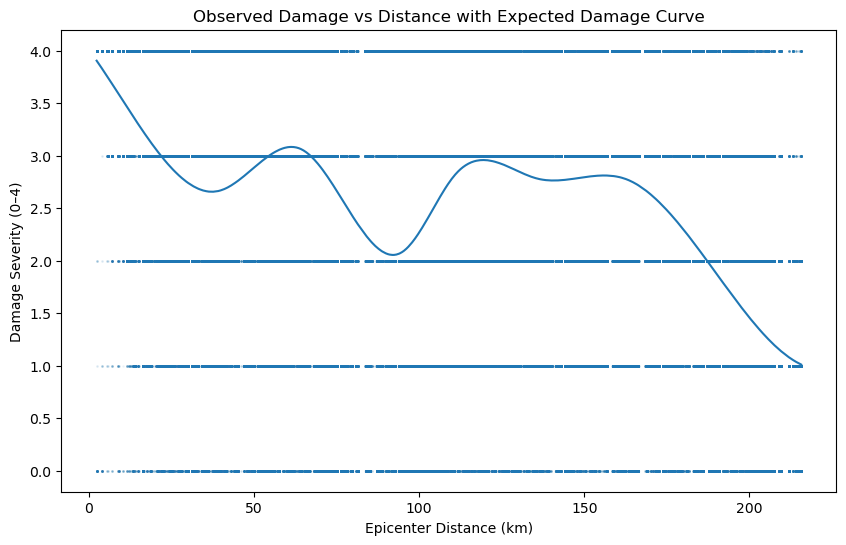

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean["epicenter_distance"],
    df_clean["damage_severity"],
    s=1,
    alpha=0.05
)

# Sort for a clean expected-damage line
plot_data = (
    df_clean
    .groupby("epicenter_distance", as_index=False)
    ["expected_damage"]
    .mean()
    .sort_values("epicenter_distance")
)

plt.plot(
    plot_data["epicenter_distance"],
    plot_data["expected_damage"]
)

plt.xlabel("Epicenter Distance (km)")
plt.ylabel("Damage Severity (0–4)")
plt.title("Observed Damage vs Distance with Expected Damage Curve")

plt.show()

# Save our results

In [ ]:
df_clean.to_csv('resilience_dataset_clean.csv', index=False)
print("File saved successfully.")

File saved successfully.


In [17]:
# Drop unnecessary columns
df_clean = pd.read_csv('resilience_dataset_clean.csv')

cols_to_drop = ["damage_severity", 'building_id', 
                'district_id', 'vdcmun_id', 'ward_id', 'expected_damage', 'performance_gap', 'distance_bin']
df_clean = df_clean.drop(columns=cols_to_drop)

In [18]:
df_clean.to_csv('resilience_dataset_final.csv', index=False)
print("File saved successfully.")

File saved successfully.


In [ ]:
for i in range(0,int(df_final["damage_grade"].max()),1):
    print(
        f"{i} to {i+1}: {df_final["damage_grade"][(df_final["damage_grade"]>i)\
                                         & (df_final["damage_grade"]<=i+1)].count()} rows"
        )

0 to 1: 78726 rows
1 to 2: 87019 rows
2 to 3: 136087 rows
3 to 4: 183516 rows
4 to 5: 274650 rows


In [ ]:
for i in range(0,int(df_final["epicenter_distance"].max()),5):
    print(
        f"{i}km to {i+5}km: {df_final["epicenter_distance"][(df_final["epicenter_distance"]>i)\
                                         & (df_final["epicenter_distance"]<=i+5)].count()} rows"
        )

0km to 5km: 1485 rows
5km to 10km: 3373 rows
10km to 15km: 7268 rows
15km to 20km: 10989 rows
20km to 25km: 17058 rows
25km to 30km: 24483 rows
30km to 35km: 21429 rows
35km to 40km: 26428 rows
40km to 45km: 17840 rows
45km to 50km: 19410 rows
50km to 55km: 28128 rows
55km to 60km: 22672 rows
60km to 65km: 19006 rows
65km to 70km: 24114 rows
70km to 75km: 22233 rows
75km to 80km: 13553 rows
80km to 85km: 9923 rows
85km to 90km: 16615 rows
90km to 95km: 22989 rows
95km to 100km: 33383 rows
100km to 105km: 35201 rows
105km to 110km: 29847 rows
110km to 115km: 30428 rows
115km to 120km: 22313 rows
120km to 125km: 20072 rows
125km to 130km: 21648 rows
130km to 135km: 17222 rows
135km to 140km: 19272 rows
140km to 145km: 17413 rows
145km to 150km: 24078 rows
150km to 155km: 19873 rows
155km to 160km: 17052 rows
160km to 165km: 22393 rows
165km to 170km: 12470 rows
170km to 175km: 13995 rows
175km to 180km: 13554 rows
180km to 185km: 7385 rows
185km to 190km: 11959 rows
190km to 195km: 7298 

In [ ]:
for i in range(0,100,5):
    print(
        f"{i}% to {i+5}%: {df_clean['resilience_score'][(df_clean['resilience_score']>i)\
                                         & (df_clean['resilience_score']<=i+5)].count()} rows"
        )

0% to 5%: 28637 rows
5% to 10%: 19708 rows
10% to 15%: 69995 rows
15% to 20%: 120425 rows
20% to 25%: 42473 rows
25% to 30%: 19124 rows
30% to 35%: 47271 rows
35% to 40%: 91678 rows
40% to 45%: 36176 rows
45% to 50%: 14329 rows
50% to 55%: 29944 rows
55% to 60%: 65960 rows
60% to 65%: 28076 rows
65% to 70%: 13106 rows
70% to 75%: 15946 rows
75% to 80%: 34516 rows
80% to 85%: 25130 rows
85% to 90%: 11329 rows
90% to 95%: 11305 rows
95% to 100%: 27128 rows


In [ ]:
df_final["epicenter_distance"].corr(df_clean['resilience_score'], method= 'spearman')

np.float64(-0.027270721283510806)

In [ ]:
df_clean[df_clean.duplicated(subset=['resilience_score'], keep=False)]

,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,...,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,epicenter_distance,resilience_score
0,1,9,288,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,...,0,0,0,0,1,0,0,0,205.726354,24.581271
1,1,15,364,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,...,0,0,0,0,1,0,0,0,205.726354,0.000000
2,1,20,384,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,...,0,0,0,0,0,0,0,0,205.726354,45.154602
3,1,20,312,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,...,0,0,0,0,0,0,0,0,205.726354,45.129319
4,1,30,308,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,...,0,0,0,0,0,0,0,0,205.726354,65.774304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
759993,2,60,165,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,Timber-Planck,Attached-2 side,...,0,0,0,0,0,0,0,0,3.882542,36.382286
759994,2,35,342,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,Timber-Planck,Attached-1 side,...,0,0,0,0,0,0,0,0,3.882542,36.581579
759995,2,35,342,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,Timber-Planck,Not attached,...,0,0,0,0,0,0,0,0,3.882542,36.971644
759996,2,19,306,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,Timber-Planck,Not attached,...,0,0,0,0,0,0,0,0,3.882542,36.971644
